# Generative Chatbot using Seq2Seq Models

This notebook supports the NLP end-of-module group assignment. The aim is to build a generative chatbot using a sequence-to-sequence approach, first without attention and then with an attention mechanism.

The project uses the CMU Question/Answer Dataset, Release 1.2. This dataset contains Wikipedia-based factual questions and manually written answers. For this work, each question is treated as the input sequence and each answer as the target sequence.

The notebook follows an experimental flow of: dataset preparation, exploratory data analysis, preprocessing, model training, evaluation, and comparison of the two chatbot models.

## Ubuntu Dialogue Corpus - Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on the Ubuntu Dialogue Corpus for a generative chatbot project.  

The aim is to inspect data quality, analyse input and response lengths, check missing values and duplicates, examine vocabulary size, and recommend preprocessing decisions for Seq2Seq chatbot models.

Step 1: Import Libraries:

This section imports the Python libraries required for the analysis. These libraries are used for data manipulation, text processing, visualisation, and basic statistical analysis.

In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from collections import Counter
from sklearn.model_selection import train_test_split
import glob
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import random
import torch.optim as optim

Step 2: Define Dataset Location:

The dataset is stored in Google Drive. This step specifies the folder containing the dialogue files so they can be loaded into the notebook.


In [108]:
DATASET_PATH = "../Data"
os.listdir(DATASET_PATH)

['dialogueText.csv',
 '.DS_Store',
 'dialogueText_301.csv',
 'Readme.md',
 'dialogueText_196.csv']

Step 3: Locate the dialogue files:

The Ubuntu Dialogue Corpus is
distributed across multiple CSV files. This step identifies all dialogue files while excluding the table of contents file (`toc.csv`), which does not contain dialogue data.

In [109]:
csv_files = glob.glob(os.path.join(DATASET_PATH, "dialogueText*.csv"))
if len (csv_files) > 0:
    print(csv_files)
else:
    print ("Dataset files not found, unable to continue.")

['../Data/dialogueText.csv', '../Data/dialogueText_301.csv', '../Data/dialogueText_196.csv']


Step 4: Combine CSV Files into one DataFrame

This step displays the column names, data types, and overall dataset structure. Understanding
 the available variables helps identify which columns will be used during the analysis.

 A 100000 samples were used this is a common practice when analysing very large datasets because it:

- Reduces memory usage and execution time.
- Prevents Google Colab from running out of RAM or timing out.
- Preserves the overall characteristics of the dataset, allowing reliable analysis of dialogue lengths, vocabulary, missing values, and duplicate records.
- Produces results that are representative of the full dataset while making the analysis reproducible by using a fixed random seed (`random_state=42`).

The full dataset would still be used during model training if computational resources allow, whereas this sample is used only for the exploratory analysis.

In [110]:
df_list = []

for file in csv_files:
    print(f"Loading {os.path.basename(file)}...")
    temp_df = pd.read_csv(file)
    temp_df["source_file"] = os.path.basename(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Loading dialogueText.csv...
Loading dialogueText_301.csv...
Loading dialogueText_196.csv...
Dataset loaded successfully.
Shape: (26839031, 7)


,folder,dialogueID,date,from,to,text,source_file
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the fol...",dialogueText.csv
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you ...,dialogueText.csv
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we...,dialogueText.csv
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t,dialogueText.csv
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?,dialogueText.csv


In [111]:
#Create df copy for pre-processing purposes. This DF is used in model pre-processing step and model training.
df_full_raw = df.copy()

In [112]:
SAMPLE_SIZE = 100000

if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).copy()

print("Sampled dataset shape:", df.shape)
df.head()

Sampled dataset shape: (100000, 7)


,folder,dialogueID,date,from,to,text,source_file
2137161,3,25107.tsv,2011-01-04T03:39:00.000Z,Guest84722,NaN,hi,dialogueText_301.csv
2152569,3,34299.tsv,2010-07-25T13:48:00.000Z,arpad2,NaN,"after refresh rate change, screen goes black i...",dialogueText_301.csv
23912183,10,58930.tsv,2005-09-11T12:07:00.000Z,Amaranth,NaN,"i thought that was all in hardware, no software",dialogueText_196.csv
8762949,11,17601.tsv,2010-05-23T15:19:00.000Z,OttifantSir,NaN,Does anyone know why ffmpeg2theora only conver...,dialogueText_301.csv
80718,3,269434.tsv,2006-10-20T15:51:00.000Z,torpor,NaN,hi all,dialogueText.csv


Step 5: Inspect columns and data types



In [113]:
print("Column names:")
print(df.columns)

df.info()

Column names:
Index(['folder', 'dialogueID', 'date', 'from', 'to', 'text', 'source_file'], dtype='str')
<class 'pandas.DataFrame'>
Index: 100000 entries, 2137161 to 21477568
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   folder       100000 non-null  int64
 1   dialogueID   100000 non-null  str  
 2   date         100000 non-null  str  
 3   from         100000 non-null  str  
 4   to           64583 non-null   str  
 5   text         99993 non-null   str  
 6   source_file  100000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 6.1 MB


Step 6: Preview Random Samples:

Random dialogue records are displayed to gain a better understanding of the dataset content and verify that the conversations have been loaded correctly.

In [114]:
df.sample(10)

,folder,dialogueID,date,from,to,text,source_file
6772035,15,24305.tsv,2006-11-22T12:51:00.000Z,Lovloss,NaN,They're plugged in for sure too,dialogueText_301.csv
11157475,51,238.tsv,2009-10-19T23:48:00.000Z,aoupi,anilalur,thanks,dialogueText_301.csv
4198158,5,80215.tsv,2008-02-21T22:16:00.000Z,hawkeye,NaN,Das erscheint nur Hibernate und Suspend. Unter...,dialogueText_301.csv
2611329,3,99389.tsv,2008-10-09T01:55:00.000Z,Dr_willis_,NaN,pal you can add the section at the end.,dialogueText_301.csv
15513451,8,6451.tsv,2011-05-19T13:46:00.000Z,vijay__,NaN,My windows is missing from boot menu can any1 ...,dialogueText_301.csv
14679622,7,36997.tsv,2009-01-31T19:29:00.000Z,Jack_Sparrow,NaN,agreed,dialogueText_301.csv
11102370,44,684.tsv,2007-06-18T10:14:00.000Z,gnomefreak,contraY,ther eis no pasting in here.,dialogueText_301.csv
8979272,38,1915.tsv,2005-10-22T14:36:00.000Z,InitMass,bluefrog-10,now it actually seems to be coming through :),dialogueText_301.csv
10250482,13,38755.tsv,2005-05-05T09:23:00.000Z,dcraven,St0n3-C0l,ahh.,dialogueText_301.csv
15732140,8,3869.tsv,2012-07-04T03:10:00.000Z,newbie|2,NaN,?,dialogueText_301.csv


Step 7: Identify text column:

The dialogue text column is selected because it contains the conversational utterances that will be analysed throughout the exploratory data analysis.

In [115]:
TEXT_COLUMN = "text"

df[[TEXT_COLUMN]].head()

,text
2137161,hi
2152569,"after refresh rate change, screen goes black i..."
23912183,"i thought that was all in hardware, no software"
8762949,Does anyone know why ffmpeg2theora only conver...
80718,hi all


Step 8: Dataset size summary:

Basic statistics describing the dataset are presented, including the number of rows, columns, and source files. This provides an overview of the dataset size.

In [116]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Total columns",
        "Number of source files"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["source_file"].nunique()
    ]
})

dataset_summary

,Metric,Value
0,Total rows,100000
1,Total columns,7
2,Number of source files,3


Step 9: Missing Values:

Missing values are identified to determine whether incomplete dialogue records exist. Missing dialogue text cannot be used to train a chatbot and should therefore be removed.

In [117]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_table

,Missing Values,Percentage
folder,0,0.000
dialogueID,0,0.000
date,0,0.000
from,0,0.000
to,35417,35.417
text,7,0.007
source_file,0,0.000


Step 10: Remove missing text rows:

Rows containing missing dialogue text are removed to improve data quality before further analysis.

In [118]:
df = df.dropna(subset=[TEXT_COLUMN]).copy()

print("Shape after removing missing text rows:", df.shape)

Shape after removing missing text rows: (99993, 7)


Step 11: Check duplicate rows:

Duplicate dialogue records are identified because repeated examples may introduce bias during model training and artificially increase the dataset size.

In [119]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 2


Step 12: Remove Duplicates:

Duplicate rows are removed to ensure that each dialogue utterance is represented only once within the dataset.

In [120]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (99991, 7)


Step 13: Clean Text

Basic text cleaning is performed by converting all text to lowercase, removing punctuation and unnecessary whitespace. These operations help standardise the dialogue text before further analysis.

In [121]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["text_clean"] = df[TEXT_COLUMN].apply(clean_text)

df[["text_clean"]].head()

,text_clean
2137161,hi
2152569,after refresh rate change screen goes black in...
23912183,i thought that was all in hardware no software
8762949,does anyone know why ffmpeg2theora only conver...
80718,hi all


Step 14: Analyse utterance lenghts:

The number of words in each dialogue utterance is calculated. Understanding the distribution of dialogue lengths helps determine an appropriate maximum sequence length for the Seq2Seq models.

In [122]:
df["text_length"] = df["text_clean"].apply(lambda x: len(x.split()))

df["text_length"].describe()

count    99991.000000
mean         9.781540
std          9.189089
min          0.000000
25%          4.000000
50%          7.000000
75%         13.000000
max        102.000000
Name: text_length, dtype: float64

Step 15: Plot utterance lenght distribution:

A histogram is used to visualise the distribution of dialogue lengths. This allows us to identify whether most utterances are short, medium, or very long.

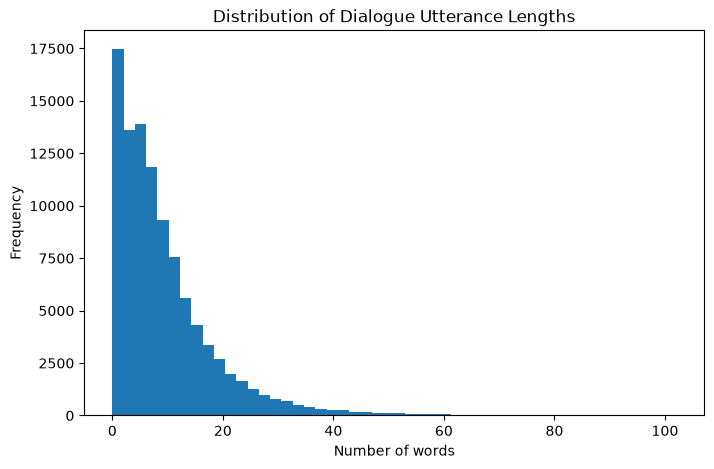

In [123]:
plt.figure(figsize=(8, 5))
plt.hist(df["text_length"], bins=50)
plt.title("Distribution of Dialogue Utterance Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Step 16: Inspect very long utterances:

The longest dialogue utterances are inspected to identify possible outliers that may need to be truncated or removed during preprocessing.

In [124]:
df.nlargest(10, "text_length")[[TEXT_COLUMN, "text_length"]]

,text,text_length
64806,I LIKE COCKS I LIKE COCKS I LIKE COCKS I LIKE ...,102
7879695,"Hello, I ude to run Fedora core 3 on my box, a...",93
12506713,hi ! I'm playing 'a fun game' in order to mast...,93
14740375,"ugh... so.. i had my hard drive fail today, lo...",93
8713566,"I have Toshiba Satellite L300 with H2O Bios, a...",92
3483864,"Hmm, well I took my computer to get fixed a co...",92
6629039,PANIC ATTACK: I have booted into live-cd of Ub...,91
23216869,PANIC ATTACK: I have booted into live-cd of Ub...,91
6174544,it's my guess. It's a mac pro using efi. I u...,90
2117160,howdy! I am across the country right now outsi...,90


Spet 17: Filter very long and empty utterances:

Dialogue utterances longer than the selected maximum length are removed. Limiting sequence length reduces computational complexity and improves training efficiency.

In [125]:
MAX_LENGTH = 30

filtered_df = df[
    (df["text_length"] > 0) &
    (df["text_length"] <= MAX_LENGTH)
].copy()

print("Original dataset size:", len(df))
print("Filtered dataset size:", len(filtered_df))
print("Rows removed:", len(df) - len(filtered_df))

Original dataset size: 99991
Filtered dataset size: 94761
Rows removed: 5230


Step 18: Plot filtered lenght distribution:

he distribution of dialogue lengths is plotted again after filtering to verify that extremely long utterances have been removed successfully.

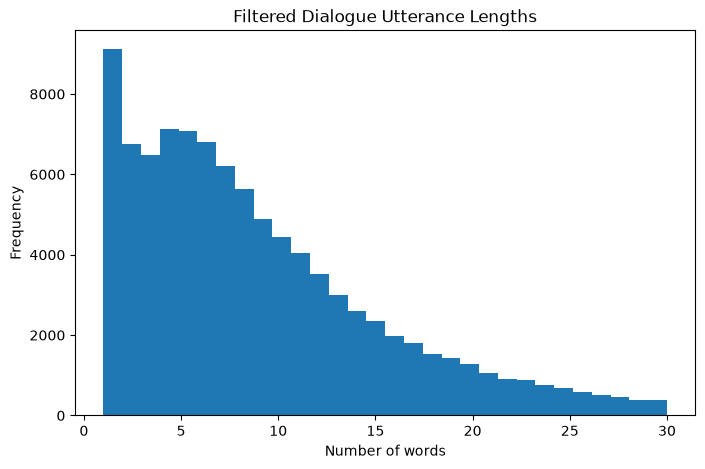

In [126]:
plt.figure(figsize=(8, 5))
plt.hist(filtered_df["text_length"], bins=30)
plt.title("Filtered Dialogue Utterance Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Step 19: Vocabulary analysis:

All dialogue text is combined to calculate the overall vocabulary size. The vocabulary represents the number of unique words present in the dataset and provides an indication of model complexity.

In [127]:
words = []

for text in filtered_df["text_clean"].astype(str):
    words.extend(text.split())

vocab_counter = Counter(words)
vocab_size = len(vocab_counter)

print("Total tokens:", len(words))
print("Vocabulary size:", vocab_size)


Total tokens: 827058
Vocabulary size: 38172


Step 20 : Top 20 most frequent words:

The twenty most frequently occurring words are identified. This provides insight into the language used throughout the Ubuntu Dialogue Corpus.

In [128]:
top_words_df = pd.DataFrame(
    vocab_counter.most_common(20),
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,i,29009
1,the,27787
2,to,23382
3,it,18427
4,you,17539
5,a,16730
6,is,13829
7,and,11893
8,that,10056
9,in,9381


Step 21: Plot top 20 words:

A bar chart is used to visualise the twenty most frequent words identified in the previous step.



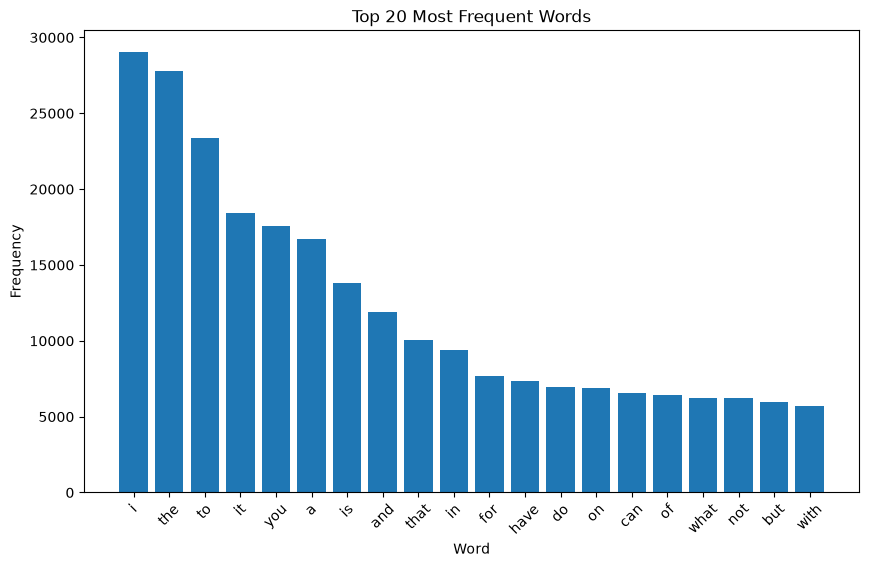

In [129]:
plt.figure(figsize=(10, 6))
plt.bar(top_words_df["Word"], top_words_df["Frequency"])
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

Step 22: Rare words analysis:

Rare words are words that appear only once within the dataset. Identifying rare words helps determine whether they should be replaced by an `<UNK>` token during preprocessing to reduce vocabulary size.

In [130]:
rare_words = [word for word, count in vocab_counter.items() if count == 1]

print("Vocabulary size:", vocab_size)
print("Rare words:", len(rare_words))
print("Percentage of vocabulary:",
      round((len(rare_words)/vocab_size)*100,2), "%")

Vocabulary size: 38172
Rare words: 25068
Percentage of vocabulary: 65.67 %


Step 23: Display some rare words:

Rare words are words that appear only once within the dataset. Identifying rare words helps determine whether they should be replaced by an `<UNK>` token during preprocessing to reduce vocabulary size.

In [131]:
print("Examples of rare words:")

rare_words[:30]

Examples of rare words:


['mikster04',
 'gn',
 '19inch',
 'avidav',
 '293',
 'yooshi',
 'cowmilk2',
 'mntbarnhouse',
 'okill',
 'itthanks',
 'usrbinphp',
 'varwwwmyscriptphp',
 'kvmamd',
 'display192168164',
 'examplepy',
 'simpleguipy',
 'compizfussion',
 'vbs',
 'namedconfoptioion',
 'robink',
 'pst',
 'vmwareand',
 'ock',
 'struggling',
 '288',
 'perlscripts',
 'usrbintclsh84',
 'resolvconftmp',
 'gdm2setup',
 'vive']

Step 24: Tokenisation:

Tokenisation is the process of splitting a sentence into smaller units called **tokens**, which are typically individual words or subword units. It is one of the fundamental preprocessing steps in Natural Language Processing (NLP).

Machine learning models cannot process raw text directly. Therefore, each dialogue utterance must first be tokenised before the tokens are converted into numerical representations (such as integer sequences or embeddings) that can be used as input to a neural network.



In [132]:
sample_text = filtered_df["text_clean"].iloc[0]

print("Original sentence:\n")
print(sample_text)

tokens = sample_text.split()

print("\nTokenised sentence:\n")
print(tokens)

print("\nNumber of tokens:", len(tokens))

Original sentence:

hi

Tokenised sentence:

['hi']

Number of tokens: 1


Step 27: Vocabulary Statistics:

Additional vocabulary statistics are presented, including the total number of unique words and average dialogue length. These statistics help estimate the complexity of the dataset.

In [133]:
average_words = filtered_df["text_length"].mean()

print(f"Average dialogue length: {average_words:.2f} words")
print(f"Shortest dialogue: {filtered_df['text_length'].min()} words")
print(f"Longest dialogue: {filtered_df['text_length'].max()} words")
print(f"Vocabulary size: {vocab_size}")

Average dialogue length: 8.73 words
Shortest dialogue: 1 words
Longest dialogue: 30 words
Vocabulary size: 38172


Step 28: EDA Summary :


The Ubuntu Dialogue Corpus was analysed to assess its suitability for developing a generative chatbot using Seq2Seq models.

The dataset consists of conversational dialogue extracted from Ubuntu IRC support channels. Data quality analysis showed that missing values and duplicate records can be removed with minimal impact on the dataset. Dialogue length analysis indicated that most utterances are relatively short, while a small number of very long utterances may need to be filtered before model training.

Vocabulary analysis showed a large number of unique words, including many rare terms that occur only once. Replacing infrequent words with an `<UNK>` token is therefore recommended to reduce model complexity.

Overall, the dataset is suitable for chatbot development following standard NLP preprocessing techniques such as text cleaning, tokenisation, vocabulary reduction, sequence padding, and train/validation/test splitting.

## Data pre-processing for Modelling

The previous exploratory analysis provided a general overview of the Ubuntu Dialogue Corpus at utterance level. 
This step is required for training both the baseline Seq2Seq model and the later attention-based model under the same preprocessing conditions.

In [134]:
# Inspecting full dataset for model preparation
print(df_full_raw.shape)
print(df_full_raw.columns)
df_full_raw.head()

(26839031, 7)
Index(['folder', 'dialogueID', 'date', 'from', 'to', 'text', 'source_file'], dtype='str')


,folder,dialogueID,date,from,to,text,source_file
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the fol...",dialogueText.csv
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you ...,dialogueText.csv
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we...,dialogueText.csv
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t,dialogueText.csv
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?,dialogueText.csv


### Construct input-response pairs

Seq2Seq chatbot training requires paired examples rather than isolated dialogue messages. Using the dialogue identifiers and timestamps available in the Ubuntu Dialogue Corpus, consecutive messages within the same dialogue are converted into input-response pairs.

In [135]:
# Remove rows without dialogue text
df_full_raw = df_full_raw.dropna(subset=["text"]).copy()
# Convert date column to datetime for ordering
df_full_raw["date"] = pd.to_datetime(df_full_raw["date"], errors="coerce")
# Remove rows where date could not be parsed
df_full_raw = df_full_raw.dropna(subset=["date"]).copy()
# Sort messages within each dialogue
df_full_raw = df_full_raw.sort_values(
    by=["source_file", "folder", "dialogueID", "date"]
).copy()

# Create next-message target within the same dialogue
df_full_raw["target_text"] = df_full_raw.groupby(
    ["source_file", "folder", "dialogueID"]
)["text"].shift(-1)

# Rename current message as input
df_full_raw["input_text"] = df_full_raw["text"]
# Keep only valid input-response pairs
df_full_raw = df_full_raw.dropna(subset=["input_text", "target_text"]).copy()
# Keep only the columns needed for modelling
df_full_raw = df_full_raw[
    ["source_file", "folder", "dialogueID", "date", "from", "to", "input_text", "target_text"]
].copy()
print("Input-response pairs created:", len(df_full_raw))
df_full_raw.head()

Input-response pairs created: 23629456


,source_file,folder,dialogueID,date,from,to,input_text,target_text
456666,dialogueText.csv,3,1.tsv,2005-05-25 11:26:00+00:00,seth,NaN,"Also guys, I'm trying to get into my FIrefox p...",are you logged in as 'root' ?
456667,dialogueText.csv,3,1.tsv,2005-05-25 11:27:00+00:00,lifeless,seth,are you logged in as 'root' ?,no.
141945,dialogueText.csv,3,10.tsv,2004-11-27 09:10:00+00:00,jdz`,NaN,ugh ;( http://planet.ubuntulinux.org seems to...,"perhaps if you define *broken* a little, we ca..."
141946,dialogueText.csv,3,10.tsv,2004-11-27 09:12:00+00:00,lifeless,jdz`,"perhaps if you define *broken* a little, we ca...",hypa7ia: Every single entry is by Tollef Fog H...
593997,dialogueText.csv,3,100.tsv,2004-10-31 11:07:00+00:00,GNU-Ubuntu,NaN,ohh to late,http://www.ubuntulinux.org/ubuntu/login.png IS...


In [136]:
# Checking column names and sample with consolidated columns added.
print (df_full_raw.columns)
print (df_full_raw.shape)
print (df_full_raw[["input_text", "target_text"]].head())

Index(['source_file', 'folder', 'dialogueID', 'date', 'from', 'to',
       'input_text', 'target_text'],
      dtype='str')
(23629456, 8)
                                               input_text  \
456666  Also guys, I'm trying to get into my FIrefox p...   
456667                      are you logged in as 'root' ?   
141945  ugh ;(  http://planet.ubuntulinux.org seems to...   
141946  perhaps if you define *broken* a little, we ca...   
593997                                        ohh to late   

                                              target_text  
456666                      are you logged in as 'root' ?  
456667                                                no.  
141945  perhaps if you define *broken* a little, we ca...  
141946  hypa7ia: Every single entry is by Tollef Fog H...  
593997  http://www.ubuntulinux.org/ubuntu/login.png IS...  


#### Find and fix rows with empty values

In [137]:
# Find null and empty values
null_and_empty_counts = df_full_raw.apply(lambda col: 
    col.isna() | col.astype(str).str.strip().eq("")
).sum()

print("--- Total Missing/Empty Values Per Column ---")
print(null_and_empty_counts)

--- Total Missing/Empty Values Per Column ---
source_file          0
folder               0
dialogueID           0
date                 0
from               459
to             9454580
input_text        2626
target_text       2114
dtype: int64


In [138]:
#Removing rows that are emtpy or null in critical fields for training: Input and target text.
bf_rows = len(df_full_raw)
df_full_raw = df_full_raw[
    df_full_raw["input_text"].notna() &
    df_full_raw["target_text"].notna() &
    df_full_raw["input_text"].astype(str).str.strip().ne("") &
    df_full_raw["target_text"].astype(str).str.strip().ne("")
].copy()

af_rows = len(df_full_raw)
print("Rows before removing empty input/target pairs:", bf_rows)
print("Rows after removing empty input/target pairs:", af_rows)
print("Rows removed:", bf_rows - af_rows)

Rows before removing empty input/target pairs: 23629456
Rows after removing empty input/target pairs: 23625361
Rows removed: 4095


**Missing and empty values in input-response pairs**

The missing-value check shows that the structural columns required to identify and order dialogues are complete. Rows with missing or empty `input_text` or `target_text` were removed, since both sides of the pair are required for supervised Seq2Seq training. Without a valid input message and a valid target response, the pair cannot contribute to model learning.

#### Light text cleaning

The following step cleans the dataset but not extensively to prevent removing meaning from messages that contain techical expressions, version numbers or similar.
Therefore, focus would be to convert to lowercases, remove unnecessary whitespace, and replaces URLs and email addresses with placeholder tokens. 
Stopword removal, stemming and aggressive punctuation removal are not applied because they could reduce the naturalness and technical meaning of the dialogue response

In [139]:
regex_url = r'https?://\S+|www\.\S+'
regex_email = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
def clean_text(text):
    text = str(text)
    text = re.sub(regex_url, ' <url> ', text)
    text = re.sub(regex_email, ' <email> ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_full_raw["input_text"] = df_full_raw["input_text"].apply(clean_text)
df_full_raw["target_text"] = df_full_raw["target_text"].apply(clean_text)

In [140]:
print (len(df_full_raw.loc[
    df_full_raw["input_text"].str.contains("<url>|<email>", na=False) |
    df_full_raw["target_text"].str.contains("<url>|<email>", na=False),
    ["input_text", "target_text"]
]))

1093579


The cleaning step replaced URLs and email addresses with `<url>` and `<email>` placeholders. This was important because multiple input-response pairs contained these patterns after cleaning. Keeping the original URLs and email addresses would have increased vocabulary sparsity without adding useful conversational structure for the Seq2Seq models.

**Post-cleaning validation**

After applying light text cleaning, the input and target texts were checked again for empty values. This validation is required because some records may become empty after normalisation or whitespace cleaning.

In [141]:
print("Empty input_text:", (df_full_raw["input_text"].str.strip().str.len() < 1).sum())
print("Empty target_text:", (df_full_raw["target_text"].str.strip().str.len() < 1).sum())

Empty input_text: 0
Empty target_text: 0


After light text cleaning, no empty values were found in either `input_text` or `target_text`. Therefore, no additional rows had to be removed at this stage.

#### Find duplicates in input/target text

In [142]:
# Find duplicates
bf_rows = len(df_full_raw)
df_full_raw[df_full_raw.duplicated(subset=["input_text", "target_text"])]
#Removing duplicates
df_full_raw = df_full_raw.drop_duplicates(subset=["input_text", "target_text"]).reset_index(drop=True)

af_rows = len(df_full_raw)
print("Rows before removing duplicated pairs:", bf_rows)
print("Rows after removing duplicated pairs:", af_rows)
print("Rows removed:", bf_rows - af_rows)

Rows before removing duplicated pairs: 23625361
Rows after removing duplicated pairs: 13641925
Rows removed: 9983436


**Exact duplicate input-response pairs**

Exact duplicate input-response pairs were removed using the combination of `input_text` and `target_text`. This was done because repeated identical pairs do not add new conversational information and may bias the model towards overrepresented exchanges.

#### Input and target length analysis

The next step is to analyse the length of the cleaned input-response pairs. This helps define practical maximum sequence lengths for the Seq2Seq models.

Both `input_text` and `target_text` are measured in word-level tokens. The results are used to identify unusually long messages and decide suitable length limits before training.

In [143]:
# Create length columns for input and target text
df_full_raw["In_length"] = df_full_raw["input_text"].str.split().str.len()
df_full_raw["Tg_length"] = df_full_raw["target_text"].str.split().str.len()

# Create token count columns. For exploratory analysis, tokens are approximated using a regular expression that counts words and punctuation marks.
df_full_raw["In_token"] = df_full_raw["input_text"].astype(str).str.findall(r'\w+|[^\w\s]').str.len()
df_full_raw["Tg_token"] = df_full_raw["target_text"].astype(str).str.findall(r'\w+|[^\w\s]').str.len()

# adding to DF to apply formating.
length_summary = df_full_raw[["In_length", "Tg_length", "In_token", "Tg_token"]].describe()
length_summary.style.format("{:,.2f}")

,In_length,Tg_length,In_token,Tg_token
count,"13,641,925.00","13,641,925.00","13,641,925.00","13,641,925.00"
mean,10.21,9.62,12.98,12.28
std,9.27,8.41,11.75,10.64
min,1.00,1.00,1.00,1.00
25%,4.00,4.00,5.00,5.00
50%,8.00,7.00,10.00,9.00
75%,13.00,13.00,17.00,16.00
max,198.00,198.00,459.00,459.00


The length analysis shows that both input and target messages are generally short. The median input length is 10 tokens, while the median target length is 9 tokens. The 75th percentile is 17 tokens for inputs and 16 tokens for targets, which suggests that most dialogue pairs are manageable for Seq2Seq training. The analysis also shows the presence of outliers with 459 tokens which may impact the complexity of the solution.

In [144]:
# Check high percentiles conversations and decide which to use for next steps.
length_percentiles = df_full_raw[["In_token", "Tg_token"]].quantile([0.90, 0.95, 0.99])
length_percentiles

,In_token,Tg_token
0.90,27.0,25.0
0.95,35.0,33.0
0.99,57.0,51.0


The percentile analysis shows that 99% of input messages contain 57 tokens or fewer, while 99% of target responses contain 51 tokens or fewer. 

For modelling, maximum sequence lengths were set close to the 99th percentile: 60 tokens for inputs and 55 tokens for targets. This retains most input-response pairs while excluding unusually long messages, such as the maximum 459-token cases, which would increase padding, memory usage and decoding complexity. The main trade-off is that using the 99th percentile preserves more conversational variety, but increases padding and training cost compared with a stricter 95th percentile threshold.

In [145]:
# Thresholds defined per previous step covering 99% of the dataset.
MAX_INPUT_LENGTH = 60
MAX_TARGET_LENGTH = 55

# Final filtering of the dataset
bf_rows = len(df_full_raw)
df_full_raw = df_full_raw[
    (df_full_raw["In_token"] <= MAX_INPUT_LENGTH) &
    (df_full_raw["Tg_token"] <= MAX_TARGET_LENGTH)
].copy()

af_rows = len(df_full_raw)
print("Rows before length filtering:", bf_rows)
print("Rows after length filtering:", af_rows)
print("Rows removed:", bf_rows - af_rows)

Rows before length filtering: 13641925
Rows after length filtering: 13439406
Rows removed: 202519


After limiting the size 202519 pairs of rows were removed. This confirms that the selected thresholds preserve the vast majority of the dataset while removing unusually long examples that would increase padding, memory usage and decoding complexity.

### Dataset Sampling

After constructing and cleaning the input-response pairs, the dataset remains too large to train Seq2Seq models from scratch within the scope and hardware constraints of this assignment. This section prepares a manageable modelling dataset by selecting a reproducible sample and building the vocabulary required to convert text into numerical sequences.

In [146]:
# Define sample size to train models.
# A reproducible random sample of 100000 input-response pairs is therefore selected for model development. This sample is required due to computing capacity and training time.
# This sample size provides substantially more conversational variety than a smaller prototype sample, while keeping training and experimentation feasible on local hardware. 
MODEL_SAMPLE_SIZE = 100000

In [147]:
# New dataframe is created so the one that is clean and ready could be preserved for future steps.
df_model = df_full_raw.sample(n=MODEL_SAMPLE_SIZE, random_state=42).copy()
print("Sampled dataset shape:", df_model.shape)
df_model.head()

Sampled dataset shape: (100000, 12)


,source_file,folder,dialogueID,date,from,to,input_text,target_text,In_length,Tg_length,In_token,Tg_token
7668620,dialogueText_196.csv,185,6.tsv,2007-03-11 07:52:00+00:00,T3hMikey,xtknight,do i need to add my resolution somewhere else ...,"yeah, i did that ctrl alt backspace thing",12,8,14,9
10765158,dialogueText_301.csv,9,43927.tsv,2008-11-07 21:15:00+00:00,theunixgeek,ardchoille,does it have qt development packages on it? :),"i don't know, but i know it doesn't have anyth...",9,14,11,21
9997303,dialogueText_301.csv,8,23499.tsv,2010-12-30 16:54:00+00:00,turneralex,mr_blue,"how come no more space? im not 100% on this, b...",<url>,28,1,35,3
2621241,dialogueText_196.csv,11,62753.tsv,2009-05-07 09:05:00+00:00,anom01y,NaN,"i have the 6200, he has the 8800 gt",we can't get past 640x480 resolution,9,6,10,8
10952956,dialogueText_301.csv,9,69008.tsv,2006-11-20 11:53:00+00:00,slavik,NaN,tell me their home directory (same part as the...,!pastebin| heiroglyphics,11,2,13,4


In [148]:
# Validation of the sampled data. Making sure that dataset is consistent and accurately represents the full DF.
print("Empty input_text:", (df_model["input_text"].str.strip().str.len() < 1).sum())
print("Empty target_text:", (df_model["target_text"].str.strip().str.len() < 1).sum())

Empty input_text: 0
Empty target_text: 0


In [149]:
# Checking for duplicates and emtpy/null values
print("Total duplicate values:", len(df_model[df_model.duplicated(subset=["input_text", "target_text"])]))
print("Empty input_text:", (df_model["input_text"].str.strip().str.len() < 1).sum())
print("Empty target_text:", (df_model["target_text"].str.strip().str.len() < 1).sum())

Total duplicate values: 0
Empty input_text: 0
Empty target_text: 0


**Final sampled modelling dataset**

After cleaning, length filtering and duplicate removal, a reproducible sample of 300,000 input-response pairs was created for model development. The sampled dataset was checked again to confirm that it contains no missing values, empty texts or exact duplicate pairs.

### Vocabulary and Sequence Preparation

Before training the models, the cleaned and sampled text data must be converted into numerical sequences. This section prepares the shared vocabulary, special tokens and sequence representation required by both chatbot architectures.

In [150]:
# Step 1. Special tokens: define tokens needed for padding, unknown words and decoder boundaries
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"  # Start of sequence
EOS_TOKEN = "<eos>"  # End of sequence
# Step 1. Special tokens: define fixed tokens for padding, unknown words and decoder sequence boundaries
vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
    SOS_TOKEN: 2,
    EOS_TOKEN: 3
}

In [151]:
# Step 2. Token frequency analysis: count tokens across input and target texts to understand vocabulary size and sparsity
token_pattern = r'<url>|<email>|\w+|[^\w\s]'
token_counts = Counter()
for text in df_model["input_text"]:
    token_counts.update(re.findall(token_pattern, str(text)))
for text in df_model["target_text"]:
    token_counts.update(re.findall(token_pattern, str(text)))

vocab_freq_df = pd.DataFrame(
    token_counts.most_common(),
    columns=["token", "frequency"]
)
print("Tokens appearing once:", sum(1 for count in token_counts.values() if count == 1))
print("Tokens appearing fewer than 3 times:", sum(1 for count in token_counts.values() if count < 3))
print("Tokens appearing fewer than 5 times:", sum(1 for count in token_counts.values() if count < 5))

vocab_freq_df.head(20)

Tokens appearing once: 28315
Tokens appearing fewer than 3 times: 34486
Tokens appearing fewer than 5 times: 38621


,token,frequency
0,.,117902
1,i,75606
2,the,66678
3,',65605
4,",",64467
5,to,53698
6,?,53151
7,it,50691
8,you,44029
9,a,37110


The initial vocabulary frequency analysis is showing that isolated punctuation marks are among the most frequent tokens. Keeping these symbols as independent vocabulary items would increase the model vocabulary without adding much useful conversational or technical meaning.
For the modelling tokenizer, isolated punctuation is to be excluded. The trade-off is that the model may lose some punctuation in generated responses.

In [153]:
# Step 2.1 Token frequency analysis: use a modelling tokenizer that preserves technical terms and excludes isolated punctuation
token_pattern = r"""
<url>|<email>|                    # URL and email placeholders
/[a-zA-Z0-9._/\-]+|               # file paths, e.g. /etc/apt/sources.list
--?[a-zA-Z0-9][a-zA-Z0-9._\-]*|   # commands/options, e.g. apt-get, --help
[a-zA-Z0-9]+(?:[._\-][a-zA-Z0-9]+)* # words, package names, versions, IP-like tokens
"""

def model_tokenize(text):
    return re.findall(token_pattern, str(text).lower(), flags=re.VERBOSE)

In [154]:
#Calling the function to replace isolated punctuation
df_model["input_tokens"] = df_model["input_text"].apply(lambda x: model_tokenize(x))
df_model["target_tokens"] = df_model["target_text"].apply(lambda x: model_tokenize(x))

print("Empty input token lists:", (df_model["input_tokens"].str.len() == 0).sum())
print("Empty target token lists:", (df_model["target_tokens"].str.len() == 0).sum())

Empty input token lists: 747
Empty target token lists: 704


In [155]:
# Step 2.2 Remove all rows that input/target tokens are empty.
bf_rows = len(df_model)
df_model = df_model[
    (df_model["input_tokens"].str.len() > 0) &
    (df_model["target_tokens"].str.len() > 0)
].copy()

af_rows = len(df_model)
print("Rows before length filtering:", bf_rows)
print("Rows after length filtering:", af_rows)
print("Rows removed:", bf_rows - af_rows)

print("Empty input token lists:", (df_model["input_tokens"].str.len() == 0).sum())
print("Empty target token lists:", (df_model["target_tokens"].str.len() == 0).sum())

print("Final modelling sample shape:", df_model.shape)

Rows before length filtering: 100000
Rows after length filtering: 98570
Rows removed: 1430
Empty input token lists: 0
Empty target token lists: 0
Final modelling sample shape: (98570, 14)


After applying the modelling tokenizer, 1k+ rows were removed because either the input or target side produced an empty token list.

In [156]:
# Step 2.3 New count of tokens but now using tokenized columns which exclude isolated punctuation for better results.
token_counts = Counter()
for tokens in df_model["input_tokens"]:
    token_counts.update(tokens)

for tokens in df_model["target_tokens"]:
    token_counts.update(tokens)

vocab_freq_df = pd.DataFrame(
    token_counts.most_common(),
    columns=["token", "frequency"]
)

print("Total unique tokens:", len(token_counts))
print("Tokens appearing once:", sum(1 for count in token_counts.values() if count == 1))
print("Tokens appearing fewer than 3 times:", sum(1 for count in token_counts.values() if count < 3))
print("Tokens appearing fewer than 5 times:", sum(1 for count in token_counts.values() if count < 5))

vocab_freq_df.head(20)

Total unique tokens: 58910
Tokens appearing once: 36847
Tokens appearing fewer than 3 times: 44062
Tokens appearing fewer than 5 times: 48856


,token,frequency
0,i,74591
1,the,66284
2,to,53144
3,it,50382
4,you,43763
5,a,36440
6,is,31226
7,and,28761
8,that,26971
9,in,21105


In [157]:
# Step 2.4 Calculate cumulative vocabulary coverage
total_token_count = vocab_freq_df["frequency"].sum()
vocab_freq_df["cumulative_frequency"] = vocab_freq_df["frequency"].cumsum()
vocab_freq_df["cumulative_coverage"] = (
    vocab_freq_df["cumulative_frequency"] / total_token_count * 100
).round(2)

vocab_freq_df.head(20)

,token,frequency,cumulative_frequency,cumulative_coverage
0,i,74591,74591,3.88
1,the,66284,140875,7.33
2,to,53144,194019,10.09
3,it,50382,244401,12.71
4,you,43763,288164,14.99
5,a,36440,324604,16.88
6,is,31226,355830,18.51
7,and,28761,384591,20.00
8,that,26971,411562,21.41
9,in,21105,432667,22.51


In [160]:
# Step 3. Vocabulary decision: select max vocab size based on cumulative coverage analysis
vocab_sizes = [10000, 15000, 20000, 30000, 50000]
for size in vocab_sizes:
    coverage = vocab_freq_df.iloc[size - 1]["cumulative_coverage"]
    print(f"Top {size:,} tokens coverage: {coverage:.2f}%")

MAX_VOCAB_SIZE = 15000

Top 10,000 tokens coverage: 96.48%
Top 15,000 tokens coverage: 97.35%
Top 20,000 tokens coverage: 97.87%
Top 30,000 tokens coverage: 98.50%
Top 50,000 tokens coverage: 99.54%


After running the vocabulary analysis and distribution a size of **15,000 tokens** is being selected because it covers 97.35% of token occurrences. Increasing the vocabulary beyond this point won't bring major improvements but the overall processing time will increase drastically.

In [161]:
# Step 4. Build word/index vocab to use. This process adds 30K records as vocabulary. All not included will be tagged as <unk>
vocab_add = vocab_freq_df.iloc[0:MAX_VOCAB_SIZE].copy()
vocab.update(zip(vocab_add['token'], range(len(vocab), len(vocab) + len(vocab_add))))
idx_vocab = {idx: word for word, idx in vocab.items()} # Builf inverse dictionary

print("Final vocabulary size:", len(vocab))
print("Expected vocabulary size:", MAX_VOCAB_SIZE + 4)


Final vocabulary size: 15004
Expected vocabulary size: 15004


In [162]:
# Step 5. Convert tokens to integer sequences: map each token to its vocabulary index and use <unk> for out-of-vocabulary tokens
df_model['input_seq'] = df_model['input_tokens'].apply(
    lambda lista: [vocab.get(token, vocab['<unk>']) for token in lista]
)
df_model['target_seq'] = df_model['target_tokens'].apply(
    lambda lista: [vocab.get(token, vocab['<unk>']) for token in lista]
)

df_model.head(10)

,source_file,folder,dialogueID,date,from,to,input_text,target_text,In_length,Tg_length,In_token,Tg_token,input_tokens,target_tokens,input_seq,target_seq
7668620,dialogueText_196.csv,185,6.tsv,2007-03-11 07:52:00+00:00,T3hMikey,xtknight,do i need to add my resolution somewhere else ...,"yeah, i did that ctrl alt backspace thing",12,8,14,9,"[do, i, need, to, add, my, resolution, somewhe...","[yeah, i, did, that, ctrl, alt, backspace, thing]","[19, 4, 49, 6, 189, 26, 526, 582, 285, 13, 12,...","[122, 4, 74, 12, 558, 445, 1880, 171]"
10765158,dialogueText_301.csv,9,43927.tsv,2008-11-07 21:15:00+00:00,theunixgeek,ardchoille,does it have qt development packages on it? :),"i don't know, but i know it doesn't have anyth...",9,14,11,21,"[does, it, have, qt, development, packages, on...","[i, don, t, know, but, i, know, it, doesn, t, ...","[70, 7, 15, 2007, 1222, 230, 18, 7]","[4, 52, 16, 47, 22, 4, 47, 7, 119, 16, 15, 153..."
9997303,dialogueText_301.csv,8,23499.tsv,2010-12-30 16:54:00+00:00,turneralex,mr_blue,"how come no more space? im not 100% on this, b...",<url>,28,1,35,3,"[how, come, no, more, space, im, not, 100, on,...",[<url>],"[32, 395, 34, 118, 392, 132, 23, 826, 18, 40, ...",[64]
2621241,dialogueText_196.csv,11,62753.tsv,2009-05-07 09:05:00+00:00,anom01y,NaN,"i have the 6200, he has the 8800 gt",we can't get past 640x480 resolution,9,6,10,8,"[i, have, the, 6200, he, has, the, 8800, gt]","[we, can, t, get, past, 640x480, resolution]","[4, 15, 5, 6346, 240, 91, 5, 7324, 2959]","[202, 17, 16, 44, 964, 2522, 526]"
10952956,dialogueText_301.csv,9,69008.tsv,2006-11-20 11:53:00+00:00,slavik,NaN,tell me their home directory (same part as the...,!pastebin| heiroglyphics,11,2,13,4,"[tell, me, their, home, directory, same, part,...","[pastebin, heiroglyphics]","[176, 41, 384, 335, 253, 120, 424, 45, 5, 170,...","[346, 1]"
5429581,dialogueText_196.csv,19,2112.tsv,2011-05-31 23:07:00+00:00,boba,plum,is it in hirens,it needs to be run from terminal,4,7,4,7,"[is, it, in, hirens]","[it, needs, to, be, run, from, terminal]","[10, 7, 13, 10058]","[7, 518, 6, 30, 86, 43, 144]"
3533138,dialogueText_196.csv,12,9662.tsv,2009-11-21 15:25:00+00:00,ActionParsnip28,NaN,"i wish, its a paid for game",hey did you get my message? i tried to 'pm' yo...,7,16,8,21,"[i, wish, its, a, paid, for, game]","[hey, did, you, get, my, message, i, tried, to...","[4, 927, 71, 9, 2793, 14, 727]","[304, 74, 8, 44, 26, 405, 4, 121, 6, 737, 8, 2..."
7224064,dialogueText_196.csv,60,400.tsv,2006-04-05 06:06:00+00:00,xstation,Xenguy,yes it seems odd please do the script it help ...,sorry don't have time for the forum atm (on my...,11,13,11,17,"[yes, it, seems, odd, please, do, the, script,...","[sorry, don, t, have, time, for, the, forum, a...","[57, 7, 242, 885, 134, 19, 5, 326, 7, 75, 715]","[137, 52, 16, 15, 136, 14, 5, 1296, 1257, 18, ..."
8768293,dialogueText_301.csv,6,164401.tsv,2005-01-19 17:43:00+00:00,Tomcat_,whorehog,i think you need to copy the menu.lst from the...,i thought the one from the livecd was good?,21,9,26,10,"[i, think, you, need, to, copy, the, menu.lst,...","[i, thought, the, one, from, the, livecd, was,...","[4, 81, 8, 49, 6, 355, 5, 1243, 43, 5, 249, 95...","[4, 321, 5, 54, 43, 5, 450, 59, 110]"
9426605,dialogueText_301.csv,7,23432.tsv,2009-11-05 02:29:00+00:00,revo_,mgmuscari,do you know the command to run to get that?,but its doing it on stock themes. emerald only...,10,14,11,15,"[do, you, know, the, command, to, run, to, get...","[but, its, doing, it, on, stock, themes, emera...","[19, 8, 47, 5, 98, 6, 86, 6, 44, 12]","[22, 71, 255, 7, 18, 2418, 1068, 1935, 88, 873..."


In [163]:
# Step 6. Add decoder boundary tokens: add <sos> at the start and <eos> at the end of each target sequence
sos_idx = vocab[SOS_TOKEN]
eos_idx = vocab[EOS_TOKEN]

df_model["target_seq"] = df_model["target_seq"].apply(
    lambda seq: [sos_idx] + seq + [eos_idx]
)
df_model[["target_tokens", "target_seq"]].head()

,target_tokens,target_seq
7668620,"[yeah, i, did, that, ctrl, alt, backspace, thing]","[2, 122, 4, 74, 12, 558, 445, 1880, 171, 3]"
10765158,"[i, don, t, know, but, i, know, it, doesn, t, ...","[2, 4, 52, 16, 47, 22, 4, 47, 7, 119, 16, 15, ..."
9997303,[<url>],"[2, 64, 3]"
2621241,"[we, can, t, get, past, 640x480, resolution]","[2, 202, 17, 16, 44, 964, 2522, 526, 3]"
10952956,"[pastebin, heiroglyphics]","[2, 346, 1, 3]"


In [164]:
# Step 7. Padding sequences: pad input and target sequences to fixed lengths for batch training
PAD_IDX = vocab[PAD_TOKEN]
MAX_INPUT_SEQ_LENGTH = 60
MAX_TARGET_SEQ_LENGTH = 57

def pad_sequence(seq, max_length):
    if len(seq) > max_length:
        return seq[:max_length]
    return seq + [PAD_IDX] * (max_length - len(seq))

df_model["input_padded"] = df_model["input_seq"].apply(
    lambda seq: pad_sequence(seq, MAX_INPUT_SEQ_LENGTH)
)

df_model["target_padded"] = df_model["target_seq"].apply(
    lambda seq: pad_sequence(seq, MAX_TARGET_SEQ_LENGTH)
)

df_model[["input_seq", "input_padded", "target_seq", "target_padded"]].head()

,input_seq,input_padded,target_seq,target_padded
7668620,"[19, 4, 49, 6, 189, 26, 526, 582, 285, 13, 12,...","[19, 4, 49, 6, 189, 26, 526, 582, 285, 13, 12,...","[2, 122, 4, 74, 12, 558, 445, 1880, 171, 3]","[2, 122, 4, 74, 12, 558, 445, 1880, 171, 3, 0,..."
10765158,"[70, 7, 15, 2007, 1222, 230, 18, 7]","[70, 7, 15, 2007, 1222, 230, 18, 7, 0, 0, 0, 0...","[2, 4, 52, 16, 47, 22, 4, 47, 7, 119, 16, 15, ...","[2, 4, 52, 16, 47, 22, 4, 47, 7, 119, 16, 15, ..."
9997303,"[32, 395, 34, 118, 392, 132, 23, 826, 18, 40, ...","[32, 395, 34, 118, 392, 132, 23, 826, 18, 40, ...","[2, 64, 3]","[2, 64, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2621241,"[4, 15, 5, 6346, 240, 91, 5, 7324, 2959]","[4, 15, 5, 6346, 240, 91, 5, 7324, 2959, 0, 0,...","[2, 202, 17, 16, 44, 964, 2522, 526, 3]","[2, 202, 17, 16, 44, 964, 2522, 526, 3, 0, 0, ..."
10952956,"[176, 41, 384, 335, 253, 120, 424, 45, 5, 170,...","[176, 41, 384, 335, 253, 120, 424, 45, 5, 170,...","[2, 346, 1, 3]","[2, 346, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."


All input and target sequences were padded to fixed lengths using the `<pad>` token. Padding is required to create uniform tensors for batch training, while the earlier length filtering step helps limit unnecessary padding.

In [204]:
# Keep only the columns required for model training and qualitative evaluation.
# df_model is maintained in case other decisions should/need to be taken later.
train_model = df_model[["input_text", "target_text", "input_padded", "target_padded"]].copy()
train_model["input_length"] = df_model["input_seq"].apply(len)

print(train_model["input_length"].min())
print(train_model["input_length"].max())
train_model.head()

1
57


,input_text,target_text,input_padded,target_padded,input_length
7668620,do i need to add my resolution somewhere else ...,"yeah, i did that ctrl alt backspace thing","[19, 4, 49, 6, 189, 26, 526, 582, 285, 13, 12,...","[2, 122, 4, 74, 12, 558, 445, 1880, 171, 3, 0,...",12
10765158,does it have qt development packages on it? :),"i don't know, but i know it doesn't have anyth...","[70, 7, 15, 2007, 1222, 230, 18, 7, 0, 0, 0, 0...","[2, 4, 52, 16, 47, 22, 4, 47, 7, 119, 16, 15, ...",8
9997303,"how come no more space? im not 100% on this, b...",<url>,"[32, 395, 34, 118, 392, 132, 23, 826, 18, 40, ...","[2, 64, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",28
2621241,"i have the 6200, he has the 8800 gt",we can't get past 640x480 resolution,"[4, 15, 5, 6346, 240, 91, 5, 7324, 2959, 0, 0,...","[2, 202, 17, 16, 44, 964, 2522, 526, 3, 0, 0, ...",9
10952956,tell me their home directory (same part as the...,!pastebin| heiroglyphics,"[176, 41, 384, 335, 253, 120, 424, 45, 5, 170,...","[2, 346, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11


In [205]:
# Step 8. Train/validation/test split: create reproducible splits
df_train, df_temp = train_test_split(
    train_model, 
    test_size=0.20,
    random_state=42, 
    shuffle=True
)

df_val, df_test = train_test_split(
    df_temp, 
    test_size=0.50, 
    random_state=42, 
    shuffle=True
)

del df_temp

In [206]:
# Step 8.1 Quick size validation of datasets created.
print("Total records created for training:", len(df_train))
print("Total records created for validation:", len(df_val))
print("Total records created for testing:", len(df_test))

Total records created for training: 78856
Total records created for validation: 9857
Total records created for testing: 9857


The modelling dataset was split into training, validation and test sets using an 80/10/10 split with a fixed random seed. This ensures that the same data partitions can be reused by both Seq2Seq models, supporting a fair comparison between the baseline and attention-based architectures.

## Seq2Seq Baseline Model without Attention

This section implements the baseline Seq2Seq chatbot model without an attention mechanism. The model uses the prepared training, validation and test splits created in the previous preprocessing stage.
The purpose of this baseline is to provide a reference point for evaluating whether the later attention-based model improves response generation.

The same prepared dataset and vocabulary can also be reused for the attention-based model to support a fair architecture comparison.

### Preparing PyTorch training objects

In [207]:
# PyTorch Dataset and DataLoader: prepare padded sequences for batch training
class BotDataset (Dataset):
    def __init__(self, dataframe) -> None:
        self.inputs = dataframe["input_padded"].tolist()
        self.targets = dataframe["target_padded"].tolist()
        self.input_lengths = dataframe["input_length"].tolist()

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_seq = torch.tensor(self.inputs[idx], dtype=torch.long)
        target_seq = torch.tensor(self.targets[idx], dtype=torch.long)
        input_length = torch.tensor(self.input_lengths[idx], dtype=torch.long)
        return input_seq, target_seq, input_length

In [208]:
train_dataset = BotDataset(df_train)
val_dataset = BotDataset(df_val)
test_dataset = BotDataset(df_test)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Training dataset size: 78856
Validation dataset size: 9857
Test dataset size: 9857


In [211]:
# Data loaders for pytorch
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [212]:
# Validate one batch
sample_input_batch, sample_target_batch, sample_input_lengths = next(iter(train_loader))
print("Input batch shape:", sample_input_batch.shape)
print("Target batch shape:", sample_target_batch.shape)
print("Input lengths shape:", sample_input_lengths.shape)
print("Input lengths min:", sample_input_lengths.min().item())
print("Input lengths max:", sample_input_lengths.max().item())

Input batch shape: torch.Size([64, 60])
Target batch shape: torch.Size([64, 57])
Input lengths shape: torch.Size([64])
Input lengths min: 1
Input lengths max: 42


The PyTorch DataLoader successfully returns batches with the expected dimensions: 64 input sequences of length 60 and 64 target sequences of length 57. This confirms that the padded sequences are ready for batch training.

In [213]:
# Device configuration: use the best available device for training
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


### Baseline architecture design
The baseline model follows a standard encoder-decoder Seq2Seq architecture without attention. The encoder reads the input message and compresses it into a final hidden state. The decoder then uses this hidden state to generate the target response token by token
GRUs are used for both the encoder and decoder because they provide gated recurrent modelling while being simpler and less computationally expensive than LSTMs. The main trade-off is that GRUs have a simpler memory structure than LSTMs, which may limit their ability to capture longer dependencies.

In [215]:
# Encoder creation
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1):
        super(EncoderGRU, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_IDX
        )
        
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
    def forward(self, input_seq, input_lengths):
        embedded = self.embedding(input_seq)
        
        packed = pack_padded_sequence(
            embedded,
            input_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        
        packed_outputs, hidden = self.gru(packed)
        
        outputs, _ = pad_packed_sequence(
            packed_outputs,
            batch_first=True
        )
        
        return outputs, hidden

In [216]:
# Decoder Definition
class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1):
        super(DecoderGRU, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        
        # Embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        
        # Decoder GRU
        self.gru = nn.GRU(
            input_size=embedding_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True
        )
        
        # Linear 
        self.out = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)
        embedded = self.embedding(input_token)
        output, hidden = self.gru(embedded, hidden)
        output = output.squeeze(1)
        predictions = self.out(output)
        return predictions, hidden

In [217]:
# Seq2Seq wrapper
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        
    def forward(self, source, target, source_lengths, teacher_forcing_ratio=0.5):
        batch_size = source.shape[0]
        target_len = target.shape[1]
        target_vocab_size = self.decoder.vocab_size
        
        # Tensor to store all decoder predictions
        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(self.device)        
        # only need the final 'hidden' state (context vector) to initialize the decoder
        encoder_outputs, hidden = self.encoder(source, source_lengths)
        # extract the first column from our target tensor
        input_token = target[:, 0]
        
        # Loop through the target sequence length word by word
        for t in range(1, target_len):            
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = output            
            # Determine if we use Teacher Forcing
            teacher_force = random.random() < teacher_forcing_ratio
            top_prediction = output.argmax(1)
            
            # If teacher_force is True, next input is the ground truth word.
            # Otherwise, use the model's own top prediction.
            input_token = target[:, t] if teacher_force else top_prediction
            
        return outputs

The baseline Seq2Seq model was successfully created using a GRU encoder and a GRU decoder without attention. The encoder compresses the input sequence into a final hidden state, which is then used by the decoder to generate the target response. This architecture provides a clear baseline for later comparison with an attention-based Seq2Seq model.

### Training configuration and model training
This section defines the training setup for the baseline Seq2Seq model. The loss function measures prediction error while ignoring padded positions, and the optimiser updates the model parameters during training. Training and validation loss are tracked across epochs to monitor learning and overfitting.

In [218]:
# Training function: run one full training epoch
def train_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    
    for source, target, source_lengths in data_loader:
        source = source.to(device)
        target = target.to(device)
        source_lengths = source_lengths.to(device)
        
        optimizer.zero_grad()
        
        output = model(source, target, source_lengths)
        
        # Ignore the first token position because it corresponds to <sos>
        output = output[:, 1:, :]
        target = target[:, 1:]
        
        # Reshape predictions and targets for CrossEntropyLoss
        output = output.reshape(-1, output.shape[-1])
        target = target.reshape(-1)
        
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    return epoch_loss / len(data_loader)

In [219]:
# Validation function: evaluate one full validation epoch without updating model weights
def validate_epoch(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        for source, target, source_lengths in data_loader:
            source = source.to(device)
            target = target.to(device)
            source_lengths = source_lengths.to(device)      
            # Teacher forcing is disabled during validation
            output = model(source, target, source_lengths, teacher_forcing_ratio=0)            
            # Ignore the first token position because it corresponds to <sos>
            output = output[:, 1:, :]
            target = target[:, 1:]        
            # Reshape for CrossEntropyLoss
            output = output.reshape(-1, output.shape[-1])
            target = target.reshape(-1)
            
            loss = criterion(output, target)
            epoch_loss += loss.item()
    
    return epoch_loss / len(data_loader)

In [220]:
# Model setup helper: build model, loss function and optimiser from a configuration
def build_training_components(config, device):
    encoder_model = EncoderGRU(
        vocab_size=config["vocab_size"],
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"]
    ).to(device)

    decoder_model = DecoderGRU(
        vocab_size=config["vocab_size"],
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"]
    ).to(device)

    bot_model = Seq2Seq(
        encoder=encoder_model,
        decoder=decoder_model,
        device=device
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    optimizer = optim.Adam(
        bot_model.parameters(),
        lr=config["learning_rate"]
    )

    return bot_model, criterion, optimizer

### Baseline training experiments
This section trains and compares baseline GRU Seq2Seq configurations using the prepared dataset, vocabulary and reusable training functions. The experiments use controlled subsets of the training and validation data to keep runtime manageable while still allowing model behaviour to be observed.

In [222]:
# Constants for evaluation
TRAIN_SUBSET_SIZE = 35000
VAL_SUBSET_SIZE = 9500
EXPERIMENT_EPOCHS = 5
EXPERIMENT_BATCH_SIZE = 64
EXPERIMENT_RANDOM_STATE = 42

#### Experiment 1: Baseline GRU configuration

**Hypothesis.**  
Using a 15,000-token vocabulary, a 256 hidden dimension and a learning rate of 0.0005 should make the baseline model more computationally manageable while still allowing it to learn useful dialogue patterns. Training loss is expected to decrease across epochs. Validation loss is expected to remain stable or decrease if the model generalises beyond the training subset.

In [223]:
# Experiment 1: baseline GRU training run
EXPERIMENT_CONFIG = {
    "experiment_id": "E1",
    "model_variant": "GRU 256 / lr 0.0005",
    "vocab_size": len(vocab),
    "embedding_dim": 256,
    "hidden_dim": 256,
    "num_layers": 1,
    "learning_rate": 0.0005,
    "batch_size": EXPERIMENT_BATCH_SIZE,
    "epochs": EXPERIMENT_EPOCHS,
    "train_subset_size": TRAIN_SUBSET_SIZE,
    "val_subset_size": VAL_SUBSET_SIZE,
    "random_state": EXPERIMENT_RANDOM_STATE
}

# Create experiment subsets
df_train_exp = df_train.sample(
    n=EXPERIMENT_CONFIG["train_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

df_val_exp = df_val.sample(
    n=EXPERIMENT_CONFIG["val_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

# Create DataLoaders
train_dataset_exp = BotDataset(df_train_exp)
val_dataset_exp = BotDataset(df_val_exp)

train_loader_exp = DataLoader(
    train_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=True
)

val_loader_exp = DataLoader(
    val_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=False
)

# Build model, loss function and optimiser
bot_model, criterion, optimizer = build_training_components(
    EXPERIMENT_CONFIG,
    device
)

# Run training
train_losses = []
val_losses = []

print("Experiment configuration")
print("-" * 40)
for key, value in EXPERIMENT_CONFIG.items():
    print(f"{key}: {value}")
print(f"device: {device}")
print(f"training batches: {len(train_loader_exp)}")
print(f"validation batches: {len(val_loader_exp)}")
print("-" * 40)

for epoch in range(EXPERIMENT_CONFIG["epochs"]):
    train_loss = train_epoch(
        model=bot_model,
        data_loader=train_loader_exp,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )
    
    val_loss = validate_epoch(
        model=bot_model,
        data_loader=val_loader_exp,
        criterion=criterion,
        device=device
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch + 1}/{EXPERIMENT_CONFIG['epochs']}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print("-" * 40)

# Store current experiment summary
experiment_summary = pd.DataFrame([{
    "experiment_id": EXPERIMENT_CONFIG["experiment_id"],
    "model_variant": EXPERIMENT_CONFIG["model_variant"],
    "vocab_size": EXPERIMENT_CONFIG["vocab_size"],
    "embedding_dim": EXPERIMENT_CONFIG["embedding_dim"],
    "hidden_dim": EXPERIMENT_CONFIG["hidden_dim"],
    "num_layers": EXPERIMENT_CONFIG["num_layers"],
    "learning_rate": EXPERIMENT_CONFIG["learning_rate"],
    "batch_size": EXPERIMENT_CONFIG["batch_size"],
    "epochs": EXPERIMENT_CONFIG["epochs"],
    "train_subset_size": EXPERIMENT_CONFIG["train_subset_size"],
    "val_subset_size": EXPERIMENT_CONFIG["val_subset_size"],
    "final_training_loss": train_losses[-1],
    "final_validation_loss": val_losses[-1],
    "best_validation_loss": min(val_losses),
    "best_epoch": val_losses.index(min(val_losses)) + 1

}])

experiment_summary

Experiment configuration
----------------------------------------
experiment_id: E1
model_variant: GRU 256 / lr 0.0005
vocab_size: 15004
embedding_dim: 256
hidden_dim: 256
num_layers: 1
learning_rate: 0.0005
batch_size: 64
epochs: 5
train_subset_size: 35000
val_subset_size: 9500
random_state: 42
device: mps
training batches: 547
validation batches: 149
----------------------------------------
Epoch 1/5
Training loss: 6.1378
Validation loss: 6.0928
----------------------------------------
Epoch 2/5
Training loss: 5.7238
Validation loss: 6.0856
----------------------------------------
Epoch 3/5
Training loss: 5.5993
Validation loss: 6.1042
----------------------------------------
Epoch 4/5
Training loss: 5.4895
Validation loss: 6.1336
----------------------------------------
Epoch 5/5
Training loss: 5.4140
Validation loss: 6.1363
----------------------------------------


,experiment_id,model_variant,vocab_size,embedding_dim,hidden_dim,num_layers,learning_rate,batch_size,epochs,train_subset_size,val_subset_size,final_training_loss,final_validation_loss,best_validation_loss,best_epoch
0,E1,GRU 256 / lr 0.0005,15004,256,256,1,0.0005,64,5,35000,9500,5.414046,6.136349,6.085557,2


**Conclusion.**  
Experiment 1 showed that the baseline GRU model was able to learn from the training subset, as training loss decreased from 6.1378 to 5.4140 across the observed epochs. However, validation loss did not improve consistently. The best validation loss was 6.0856 at epoch 2, after which validation performance declined. This suggests that the model began fitting the training data but did not generalise better with additional epochs, indicating early overfitting or a validation plateau.

#### Experiment 2: Lower learning rate

**Hypothesis.**
Reducing the learning rate from 0.0005 to 0.00025 should make the model updates smaller and may improve validation stability. Training loss is still expected to decrease, but more gradually than in Experiment 1. If the higher learning rate was causing unstable generalisation, Experiment 2 should produce a lower or more stable validation loss.

In [224]:
# Experiment 2: lower learning rate training run
EXPERIMENT_CONFIG = {
    "experiment_id": "E2",
    "model_variant": "GRU 256 / lr 0.00025",
    "vocab_size": len(vocab),
    "embedding_dim": 256,
    "hidden_dim": 256,
    "num_layers": 1,
    "learning_rate": 0.00025,
    "batch_size": EXPERIMENT_BATCH_SIZE,
    "epochs": EXPERIMENT_EPOCHS,
    "train_subset_size": TRAIN_SUBSET_SIZE,
    "val_subset_size": VAL_SUBSET_SIZE,
    "random_state": EXPERIMENT_RANDOM_STATE
}

# Create experiment subsets
df_train_exp = df_train.sample(
    n=EXPERIMENT_CONFIG["train_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

df_val_exp = df_val.sample(
    n=EXPERIMENT_CONFIG["val_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

# Create DataLoaders
train_dataset_exp = BotDataset(df_train_exp)
val_dataset_exp = BotDataset(df_val_exp)

train_loader_exp = DataLoader(
    train_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=True
)

val_loader_exp = DataLoader(
    val_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=False
)

# Build model, loss function and optimiser
bot_model, criterion, optimizer = build_training_components(
    EXPERIMENT_CONFIG,
    device
)

# Run training
train_losses = []
val_losses = []

print("Experiment configuration")
print("-" * 40)
for key, value in EXPERIMENT_CONFIG.items():
    print(f"{key}: {value}")
print(f"device: {device}")
print(f"training batches: {len(train_loader_exp)}")
print(f"validation batches: {len(val_loader_exp)}")
print("-" * 40)

for epoch in range(EXPERIMENT_CONFIG["epochs"]):
    train_loss = train_epoch(
        model=bot_model,
        data_loader=train_loader_exp,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )
    
    val_loss = validate_epoch(
        model=bot_model,
        data_loader=val_loader_exp,
        criterion=criterion,
        device=device
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch + 1}/{EXPERIMENT_CONFIG['epochs']}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print("-" * 40)

# Store current experiment summary
new_experiment_result = pd.DataFrame([{
    "experiment_id": EXPERIMENT_CONFIG["experiment_id"],
    "model_variant": EXPERIMENT_CONFIG["model_variant"],
    "vocab_size": EXPERIMENT_CONFIG["vocab_size"],
    "embedding_dim": EXPERIMENT_CONFIG["embedding_dim"],
    "hidden_dim": EXPERIMENT_CONFIG["hidden_dim"],
    "num_layers": EXPERIMENT_CONFIG["num_layers"],
    "learning_rate": EXPERIMENT_CONFIG["learning_rate"],
    "batch_size": EXPERIMENT_CONFIG["batch_size"],
    "epochs": EXPERIMENT_CONFIG["epochs"],
    "train_subset_size": EXPERIMENT_CONFIG["train_subset_size"],
    "val_subset_size": EXPERIMENT_CONFIG["val_subset_size"],
    "final_training_loss": train_losses[-1],
    "final_validation_loss": val_losses[-1],
    "best_validation_loss": min(val_losses),
    "best_epoch": val_losses.index(min(val_losses)) + 1
}])

experiment_summary = pd.concat(
    [experiment_summary, new_experiment_result],
    ignore_index=True
)

experiment_summary

Experiment configuration
----------------------------------------
experiment_id: E2
model_variant: GRU 256 / lr 0.00025
vocab_size: 15004
embedding_dim: 256
hidden_dim: 256
num_layers: 1
learning_rate: 0.00025
batch_size: 64
epochs: 5
train_subset_size: 35000
val_subset_size: 9500
random_state: 42
device: mps
training batches: 547
validation batches: 149
----------------------------------------
Epoch 1/5
Training loss: 6.2944
Validation loss: 6.0627
----------------------------------------
Epoch 2/5
Training loss: 5.8226
Validation loss: 6.0619
----------------------------------------
Epoch 3/5
Training loss: 5.7149
Validation loss: 6.0633
----------------------------------------
Epoch 4/5
Training loss: 5.6449
Validation loss: 6.0721
----------------------------------------
Epoch 5/5
Training loss: 5.5867
Validation loss: 6.0771
----------------------------------------


,experiment_id,model_variant,vocab_size,embedding_dim,hidden_dim,num_layers,learning_rate,batch_size,epochs,train_subset_size,val_subset_size,final_training_loss,final_validation_loss,best_validation_loss,best_epoch
0,E1,GRU 256 / lr 0.0005,15004,256,256,1,0.00050,64,5,35000,9500,5.414046,6.136349,6.085557,2
1,E2,GRU 256 / lr 0.00025,15004,256,256,1,0.00025,64,5,35000,9500,5.586660,6.077061,6.061885,2


**Conclusion.**  
Experiment 2 produced a more stable validation result than Experiment 1. Training loss decreased from 6.2944 to 5.5867, showing that the model learned from the training subset. The best validation loss was 6.0619 at epoch 2, after which validation loss gradually increased. This suggests that reducing the learning rate improved early generalisation, although the model still reached a validation plateau quickly.

#### Experiment 3: Going lower with learning rate

**Hypothesis.**  
Reducing the learning rate further to 0.0001 may produce even smoother validation behaviour, but training loss may decrease more slowly. If Experiment 2 was still updating the model too aggressively, Experiment 3 should achieve a similar or slightly lower validation loss.

In [225]:
# Experiment 3: further reduced learning rate training run
EXPERIMENT_CONFIG = {
    "experiment_id": "E3",
    "model_variant": "GRU 256 / lr 0.0001",
    "vocab_size": len(vocab),
    "embedding_dim": 256,
    "hidden_dim": 256,
    "num_layers": 1,
    "learning_rate": 0.0001,
    "batch_size": EXPERIMENT_BATCH_SIZE,
    "epochs": EXPERIMENT_EPOCHS,
    "train_subset_size": TRAIN_SUBSET_SIZE,
    "val_subset_size": VAL_SUBSET_SIZE,
    "random_state": EXPERIMENT_RANDOM_STATE
}

# Create experiment subsets
df_train_exp = df_train.sample(
    n=EXPERIMENT_CONFIG["train_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

df_val_exp = df_val.sample(
    n=EXPERIMENT_CONFIG["val_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

# Create DataLoaders
train_dataset_exp = BotDataset(df_train_exp)
val_dataset_exp = BotDataset(df_val_exp)

train_loader_exp = DataLoader(
    train_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=True
)

val_loader_exp = DataLoader(
    val_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=False
)

# Build model, loss function and optimiser
bot_model, criterion, optimizer = build_training_components(
    EXPERIMENT_CONFIG,
    device
)

# Run training
train_losses = []
val_losses = []

print("Experiment configuration")
print("-" * 40)
for key, value in EXPERIMENT_CONFIG.items():
    print(f"{key}: {value}")
print(f"device: {device}")
print(f"training batches: {len(train_loader_exp)}")
print(f"validation batches: {len(val_loader_exp)}")
print("-" * 40)

for epoch in range(EXPERIMENT_CONFIG["epochs"]):
    train_loss = train_epoch(
        model=bot_model,
        data_loader=train_loader_exp,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )
    
    val_loss = validate_epoch(
        model=bot_model,
        data_loader=val_loader_exp,
        criterion=criterion,
        device=device
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch + 1}/{EXPERIMENT_CONFIG['epochs']}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print("-" * 40)

# Store current experiment summary
new_experiment_result = pd.DataFrame([{
    "experiment_id": EXPERIMENT_CONFIG["experiment_id"],
    "model_variant": EXPERIMENT_CONFIG["model_variant"],
    "vocab_size": EXPERIMENT_CONFIG["vocab_size"],
    "embedding_dim": EXPERIMENT_CONFIG["embedding_dim"],
    "hidden_dim": EXPERIMENT_CONFIG["hidden_dim"],
    "num_layers": EXPERIMENT_CONFIG["num_layers"],
    "learning_rate": EXPERIMENT_CONFIG["learning_rate"],
    "batch_size": EXPERIMENT_CONFIG["batch_size"],
    "epochs": EXPERIMENT_CONFIG["epochs"],
    "train_subset_size": EXPERIMENT_CONFIG["train_subset_size"],
    "val_subset_size": EXPERIMENT_CONFIG["val_subset_size"],
    "final_training_loss": train_losses[-1],
    "final_validation_loss": val_losses[-1],
    "best_validation_loss": min(val_losses),
    "best_epoch": val_losses.index(min(val_losses)) + 1
}])

experiment_summary = pd.concat(
    [experiment_summary, new_experiment_result],
    ignore_index=True
)

experiment_summary

Experiment configuration
----------------------------------------
experiment_id: E3
model_variant: GRU 256 / lr 0.0001
vocab_size: 15004
embedding_dim: 256
hidden_dim: 256
num_layers: 1
learning_rate: 0.0001
batch_size: 64
epochs: 5
train_subset_size: 35000
val_subset_size: 9500
random_state: 42
device: mps
training batches: 547
validation batches: 149
----------------------------------------
Epoch 1/5
Training loss: 6.6034
Validation loss: 6.0874
----------------------------------------
Epoch 2/5
Training loss: 5.9841
Validation loss: 6.0615
----------------------------------------
Epoch 3/5
Training loss: 5.8862
Validation loss: 6.0572
----------------------------------------
Epoch 4/5
Training loss: 5.8122
Validation loss: 6.0595
----------------------------------------
Epoch 5/5
Training loss: 5.7635
Validation loss: 6.0574
----------------------------------------


,experiment_id,model_variant,vocab_size,embedding_dim,hidden_dim,num_layers,learning_rate,batch_size,epochs,train_subset_size,val_subset_size,final_training_loss,final_validation_loss,best_validation_loss,best_epoch
0,E1,GRU 256 / lr 0.0005,15004,256,256,1,0.00050,64,5,35000,9500,5.414046,6.136349,6.085557,2
1,E2,GRU 256 / lr 0.00025,15004,256,256,1,0.00025,64,5,35000,9500,5.586660,6.077061,6.061885,2
2,E3,GRU 256 / lr 0.0001,15004,256,256,1,0.00010,64,5,35000,9500,5.763527,6.057363,6.057206,3


**Conclusion.**  
Experiment 3 produced the best validation result so far. Training loss decreased from 6.6034 to 5.7635, showing that the model continued to learn with the lower learning rate. Validation loss improved until epoch 3, reaching the best value of 6.0572, and then remained almost stable. This suggests that a learning rate of 0.0001 provided smoother training and slightly better generalisation than the higher learning rates tested in Experiments 1 and 2.

#### Experiment 4: Extended training with early stopping

**Hypothesis.**  
Extending training to 10 epochs may allow the lower learning rate from Experiment 3 to continue improving gradually. However, early stopping is used to stop training if validation loss does not improve, reducing unnecessary training and limiting overfitting.

In [226]:
# Experiment 4: extended training with early stopping
EXPERIMENT_CONFIG = {
    "experiment_id": "E4",
    "model_variant": "GRU 256 / lr 0.0001 / early stopping",
    "vocab_size": len(vocab),
    "embedding_dim": 256,
    "hidden_dim": 256,
    "num_layers": 1,
    "early_stopping_patience": 2,
    "learning_rate": 0.0001,
    "batch_size": EXPERIMENT_BATCH_SIZE,
    "epochs": 10,
    "train_subset_size": TRAIN_SUBSET_SIZE,
    "val_subset_size": VAL_SUBSET_SIZE,
    "random_state": EXPERIMENT_RANDOM_STATE
}

# Create experiment subsets
df_train_exp = df_train.sample(
    n=EXPERIMENT_CONFIG["train_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

df_val_exp = df_val.sample(
    n=EXPERIMENT_CONFIG["val_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

# Create DataLoaders
train_dataset_exp = BotDataset(df_train_exp)
val_dataset_exp = BotDataset(df_val_exp)

train_loader_exp = DataLoader(
    train_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=True
)

val_loader_exp = DataLoader(
    val_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=False
)

# Build model, loss function and optimiser
bot_model, criterion, optimizer = build_training_components(
    EXPERIMENT_CONFIG,
    device
)

# Run training
train_losses = []
val_losses = []

print("Experiment configuration")
print("-" * 40)

for key, value in EXPERIMENT_CONFIG.items():
    print(f"{key}: {value}")

print(f"device: {device}")
print(f"training batches: {len(train_loader_exp)}")
print(f"validation batches: {len(val_loader_exp)}")
print("-" * 40)

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
PATIENCE = EXPERIMENT_CONFIG["early_stopping_patience"]

for epoch in range(EXPERIMENT_CONFIG["epochs"]):
    train_loss = train_epoch(
        model=bot_model,
        data_loader=train_loader_exp,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )
    
    val_loss = validate_epoch(
        model=bot_model,
        data_loader=val_loader_exp,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{EXPERIMENT_CONFIG['epochs']}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Best validation loss so far: {best_val_loss:.4f}")
    print(f"Patience counter: {patience_counter}/{PATIENCE}")
    print("-" * 40)

    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

# Store current experiment summary
new_experiment_result = pd.DataFrame([{
    "experiment_id": EXPERIMENT_CONFIG["experiment_id"],
    "model_variant": EXPERIMENT_CONFIG["model_variant"],
    "vocab_size": EXPERIMENT_CONFIG["vocab_size"],
    "embedding_dim": EXPERIMENT_CONFIG["embedding_dim"],
    "hidden_dim": EXPERIMENT_CONFIG["hidden_dim"],
    "num_layers": EXPERIMENT_CONFIG["num_layers"],
    "learning_rate": EXPERIMENT_CONFIG["learning_rate"],
    "batch_size": EXPERIMENT_CONFIG["batch_size"],
    "epochs": len(train_losses),
    "train_subset_size": EXPERIMENT_CONFIG["train_subset_size"],
    "val_subset_size": EXPERIMENT_CONFIG["val_subset_size"],
    "final_training_loss": train_losses[-1],
    "final_validation_loss": val_losses[-1],
    "best_validation_loss": best_val_loss,
    "best_epoch": best_epoch
}])

experiment_summary = pd.concat(
    [experiment_summary, new_experiment_result],
    ignore_index=True
)

experiment_summary

Experiment configuration
----------------------------------------
experiment_id: E4
model_variant: GRU 256 / lr 0.0001 / early stopping
vocab_size: 15004
embedding_dim: 256
hidden_dim: 256
num_layers: 1
early_stopping_patience: 2
learning_rate: 0.0001
batch_size: 64
epochs: 10
train_subset_size: 35000
val_subset_size: 9500
random_state: 42
device: mps
training batches: 547
validation batches: 149
----------------------------------------
Epoch 1/10
Training loss: 6.6415
Validation loss: 6.0855
Best validation loss so far: 6.0855
Patience counter: 0/2
----------------------------------------
Epoch 2/10
Training loss: 5.9803
Validation loss: 6.0633
Best validation loss so far: 6.0633
Patience counter: 0/2
----------------------------------------
Epoch 3/10
Training loss: 5.8830
Validation loss: 6.0604
Best validation loss so far: 6.0604
Patience counter: 0/2
----------------------------------------
Epoch 4/10
Training loss: 5.8222
Validation loss: 6.0567
Best validation loss so far: 6.056

,experiment_id,model_variant,vocab_size,embedding_dim,hidden_dim,num_layers,learning_rate,batch_size,epochs,train_subset_size,val_subset_size,final_training_loss,final_validation_loss,best_validation_loss,best_epoch
0,E1,GRU 256 / lr 0.0005,15004,256,256,1,0.00050,64,5,35000,9500,5.414046,6.136349,6.085557,2
1,E2,GRU 256 / lr 0.00025,15004,256,256,1,0.00025,64,5,35000,9500,5.586660,6.077061,6.061885,2
2,E3,GRU 256 / lr 0.0001,15004,256,256,1,0.00010,64,5,35000,9500,5.763527,6.057363,6.057206,3
3,E4,GRU 256 / lr 0.0001 / early stopping,15004,256,256,1,0.00010,64,6,35000,9500,5.717532,6.059798,6.056725,4


**Conclusion.**  
Experiment 4 tested whether extending training with early stopping could improve the best learning rate configuration from Experiment 3. Training loss decreased from 6.6415 to 5.7175 before early stopping was triggered at epoch 6. The best validation loss was 6.0567 at epoch 4, only slightly better than Experiment 3. This suggests that early stopping helped avoid unnecessary training, but the baseline model still reached a validation plateau quickly.

#### Experiment 5: Larger hidden state and training subset

**Hypothesis.**  
Increasing the GRU hidden dimension to 512 and expanding the training subset to 50,000 examples may improve the baseline model by giving it more capacity and exposing it to more dialogue patterns. However, this configuration is expected to be more computationally expensive and may increase the risk of overfitting if the larger model fits the training data without improving validation loss.

In [227]:
# Experiment 5: further reduced learning rate training run
EXPERIMENT_CONFIG = {
    "experiment_id": "E5",
    "model_variant": "GRU 512 / 50K train / lr 0.0001",
    "vocab_size": len(vocab),
    "embedding_dim": 256,
    "hidden_dim": 512,
    "num_layers": 1,
    "learning_rate": 0.0001,
    "batch_size": EXPERIMENT_BATCH_SIZE,
    "epochs": EXPERIMENT_EPOCHS,
    "train_subset_size": 50000,
    "val_subset_size": VAL_SUBSET_SIZE,
    "random_state": EXPERIMENT_RANDOM_STATE
}

# Create experiment subsets
df_train_exp = df_train.sample(
    n=EXPERIMENT_CONFIG["train_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

df_val_exp = df_val.sample(
    n=EXPERIMENT_CONFIG["val_subset_size"],
    random_state=EXPERIMENT_CONFIG["random_state"]
).reset_index(drop=True)

# Create DataLoaders
train_dataset_exp = BotDataset(df_train_exp)
val_dataset_exp = BotDataset(df_val_exp)

train_loader_exp = DataLoader(
    train_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=True
)

val_loader_exp = DataLoader(
    val_dataset_exp,
    batch_size=EXPERIMENT_CONFIG["batch_size"],
    shuffle=False
)

# Build model, loss function and optimiser
bot_model, criterion, optimizer = build_training_components(
    EXPERIMENT_CONFIG,
    device
)

# Run training
train_losses = []
val_losses = []

print("Experiment configuration")
print("-" * 40)
for key, value in EXPERIMENT_CONFIG.items():
    print(f"{key}: {value}")
print(f"device: {device}")
print(f"training batches: {len(train_loader_exp)}")
print(f"validation batches: {len(val_loader_exp)}")
print("-" * 40)

for epoch in range(EXPERIMENT_CONFIG["epochs"]):
    train_loss = train_epoch(
        model=bot_model,
        data_loader=train_loader_exp,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )
    
    val_loss = validate_epoch(
        model=bot_model,
        data_loader=val_loader_exp,
        criterion=criterion,
        device=device
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch + 1}/{EXPERIMENT_CONFIG['epochs']}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print("-" * 40)

# Store current experiment summary
new_experiment_result = pd.DataFrame([{
    "experiment_id": EXPERIMENT_CONFIG["experiment_id"],
    "model_variant": EXPERIMENT_CONFIG["model_variant"],
    "vocab_size": EXPERIMENT_CONFIG["vocab_size"],
    "embedding_dim": EXPERIMENT_CONFIG["embedding_dim"],
    "hidden_dim": EXPERIMENT_CONFIG["hidden_dim"],
    "num_layers": EXPERIMENT_CONFIG["num_layers"],
    "learning_rate": EXPERIMENT_CONFIG["learning_rate"],
    "batch_size": EXPERIMENT_CONFIG["batch_size"],
    "epochs": EXPERIMENT_CONFIG["epochs"],
    "train_subset_size": EXPERIMENT_CONFIG["train_subset_size"],
    "val_subset_size": EXPERIMENT_CONFIG["val_subset_size"],
    "final_training_loss": train_losses[-1],
    "final_validation_loss": val_losses[-1],
    "best_validation_loss": min(val_losses),
    "best_epoch": val_losses.index(min(val_losses)) + 1
}])

experiment_summary = pd.concat(
    [experiment_summary, new_experiment_result],
    ignore_index=True
)

experiment_summary

Experiment configuration
----------------------------------------
experiment_id: E5
model_variant: GRU 512 / 50K train / lr 0.0001
vocab_size: 15004
embedding_dim: 256
hidden_dim: 512
num_layers: 1
learning_rate: 0.0001
batch_size: 64
epochs: 5
train_subset_size: 50000
val_subset_size: 9500
random_state: 42
device: mps
training batches: 782
validation batches: 149
----------------------------------------
Epoch 1/5
Training loss: 6.2523
Validation loss: 6.0623
----------------------------------------
Epoch 2/5
Training loss: 5.8331
Validation loss: 6.0440
----------------------------------------
Epoch 3/5
Training loss: 5.7269
Validation loss: 6.0464
----------------------------------------
Epoch 4/5
Training loss: 5.6531
Validation loss: 6.0482
----------------------------------------
Epoch 5/5
Training loss: 5.6116
Validation loss: 6.0527
----------------------------------------


,experiment_id,model_variant,vocab_size,embedding_dim,hidden_dim,num_layers,learning_rate,batch_size,epochs,train_subset_size,val_subset_size,final_training_loss,final_validation_loss,best_validation_loss,best_epoch
0,E1,GRU 256 / lr 0.0005,15004,256,256,1,0.00050,64,5,35000,9500,5.414046,6.136349,6.085557,2
1,E2,GRU 256 / lr 0.00025,15004,256,256,1,0.00025,64,5,35000,9500,5.586660,6.077061,6.061885,2
2,E3,GRU 256 / lr 0.0001,15004,256,256,1,0.00010,64,5,35000,9500,5.763527,6.057363,6.057206,3
3,E4,GRU 256 / lr 0.0001 / early stopping,15004,256,256,1,0.00010,64,6,35000,9500,5.717532,6.059798,6.056725,4
4,E5,GRU 512 / 50K train / lr 0.0001,15004,256,512,1,0.00010,64,5,50000,9500,5.611619,6.052720,6.044044,2


**Conclusion.**  
Experiment 5 achieved the best validation result among the baseline experiments. Increasing the hidden dimension to 512 and expanding the training subset to 50,000 examples reduced the best validation loss to 6.0440 at epoch 2. Training loss also decreased from 6.2523 to 5.6116, showing that the larger model continued to learn from the training data. However, validation loss increased slightly after epoch 2, suggesting that the larger configuration improved generalisation only marginally before reaching a plateau.

Overall, the experiments show that the baseline GRU Seq2Seq model learned from the training data, but validation improvements were modest. The best configuration was Experiment 5, which used a 512-dimensional hidden state and a 50,000-example training subset. This configuration achieved the lowest validation loss, but the improvement over smaller models was limited, suggesting that the baseline architecture has restricted generalisation capacity without attention.

### Final baseline model selection and training

The final baseline model was selected using validation performance from the training experiments. Experiment 5 achieved the lowest validation loss, using a 512-dimensional GRU hidden state, a 50,000-example training subset and a learning rate of 0.0001.
Since the best validation loss in Experiment 5 was reached at epoch 2, the final baseline model is trained using the same configuration for two epochs before test evaluation.

In [228]:
# Final baseline configuration selected from the experiment results
FINAL_BASELINE_CONFIG = {
    "experiment_id": "Final",
    "model_variant": "GRU 512 / 50K train / lr 0.0001 / packed inputs",
    "vocab_size": len(vocab),
    "embedding_dim": 256,
    "hidden_dim": 512,
    "num_layers": 1,
    "learning_rate": 0.0001,
    "batch_size": 64,
    "epochs": 2,
    "train_subset_size": 50000,
    "val_subset_size": VAL_SUBSET_SIZE,
    "random_state": EXPERIMENT_RANDOM_STATE
}

FINAL_BASELINE_CONFIG

{'experiment_id': 'Final',
 'model_variant': 'GRU 512 / 50K train / lr 0.0001 / packed inputs',
 'vocab_size': 15004,
 'embedding_dim': 256,
 'hidden_dim': 512,
 'num_layers': 1,
 'learning_rate': 0.0001,
 'batch_size': 64,
 'epochs': 2,
 'train_subset_size': 50000,
 'val_subset_size': 9500,
 'random_state': 42}

In [229]:
# Train the final baseline model
# Create final training and validation subsets
df_train_final = df_train.sample(
    n=FINAL_BASELINE_CONFIG["train_subset_size"],
    random_state=FINAL_BASELINE_CONFIG["random_state"]
).reset_index(drop=True)

df_val_final = df_val.sample(
    n=FINAL_BASELINE_CONFIG["val_subset_size"],
    random_state=FINAL_BASELINE_CONFIG["random_state"]
).reset_index(drop=True)

# Create final DataLoaders
train_dataset_final = BotDataset(df_train_final)
val_dataset_final = BotDataset(df_val_final)

train_loader_final = DataLoader(
    train_dataset_final,
    batch_size=FINAL_BASELINE_CONFIG["batch_size"],
    shuffle=True
)

val_loader_final = DataLoader(
    val_dataset_final,
    batch_size=FINAL_BASELINE_CONFIG["batch_size"],
    shuffle=False
)

# Build final model, loss function and optimiser
final_bot_model, final_criterion, final_optimizer = build_training_components(
    FINAL_BASELINE_CONFIG,
    device
)

# Train final baseline model
final_train_losses = []
final_val_losses = []

print("Final baseline configuration")
print("-" * 40)

for key, value in FINAL_BASELINE_CONFIG.items():
    print(f"{key}: {value}")

print(f"device: {device}")
print(f"training batches: {len(train_loader_final)}")
print(f"validation batches: {len(val_loader_final)}")
print("-" * 40)

for epoch in range(FINAL_BASELINE_CONFIG["epochs"]):
    train_loss = train_epoch(
        model=final_bot_model,
        data_loader=train_loader_final,
        optimizer=final_optimizer,
        criterion=final_criterion,
        device=device
    )
    
    val_loss = validate_epoch(
        model=final_bot_model,
        data_loader=val_loader_final,
        criterion=final_criterion,
        device=device
    )
    
    final_train_losses.append(train_loss)
    final_val_losses.append(val_loss)
    
    print(f"Epoch {epoch + 1}/{FINAL_BASELINE_CONFIG['epochs']}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print("-" * 40)

Final baseline configuration
----------------------------------------
experiment_id: Final
model_variant: GRU 512 / 50K train / lr 0.0001 / packed inputs
vocab_size: 15004
embedding_dim: 256
hidden_dim: 512
num_layers: 1
learning_rate: 0.0001
batch_size: 64
epochs: 2
train_subset_size: 50000
val_subset_size: 9500
random_state: 42
device: mps
training batches: 782
validation batches: 149
----------------------------------------
Epoch 1/2
Training loss: 6.2597
Validation loss: 6.0529
----------------------------------------
Epoch 2/2
Training loss: 5.8321
Validation loss: 6.0438
----------------------------------------


### Final baseline test evaluation
The selected baseline model is now evaluated on the held-out test set. The test set was not used during training or model selection, so this result provides a final estimate of how the baseline Seq2Seq model performs on unseen dialogue pairs.

In [230]:
# Evaluate the final baseline model on the test set
test_dataset_final = BotDataset(df_test)
test_loader_final = DataLoader(
    test_dataset_final,
    batch_size=FINAL_BASELINE_CONFIG["batch_size"],
    shuffle=False
)

final_test_loss = validate_epoch(
    model=final_bot_model,
    data_loader=test_loader_final,
    criterion=final_criterion,
    device=device
)

print("Final baseline test loss:", round(final_test_loss, 4))

Final baseline test loss: 6.0628


In [231]:
# Store final baseline evaluation results
final_baseline_results = pd.DataFrame([{
    "model_variant": FINAL_BASELINE_CONFIG["model_variant"],
    "vocab_size": FINAL_BASELINE_CONFIG["vocab_size"],
    "embedding_dim": FINAL_BASELINE_CONFIG["embedding_dim"],
    "hidden_dim": FINAL_BASELINE_CONFIG["hidden_dim"],
    "learning_rate": FINAL_BASELINE_CONFIG["learning_rate"],
    "batch_size": FINAL_BASELINE_CONFIG["batch_size"],
    "epochs": FINAL_BASELINE_CONFIG["epochs"],
    "train_subset_size": FINAL_BASELINE_CONFIG["train_subset_size"],
    "final_training_loss": final_train_losses[-1],
    "final_validation_loss": final_val_losses[-1],
    "final_test_loss": final_test_loss
}])

final_baseline_results

,model_variant,vocab_size,embedding_dim,hidden_dim,learning_rate,batch_size,epochs,train_subset_size,final_training_loss,final_validation_loss,final_test_loss
0,GRU 512 / 50K train / lr 0.0001 / packed inputs,15004,256,512,0.0001,64,2,50000,5.832064,6.043758,6.062793


The final baseline model achieved a test loss of 6.0628. This is close to the validation loss observed during model selection, suggesting that the model generalised consistently to unseen dialogue pairs. However, the loss remains relatively high, indicating that the baseline Seq2Seq model has limited response-generation capability. This is expected because the decoder relies only on the encoder final hidden state and does not use an attention mechanism.

### Baseline response generation

This section tests the selected baseline model as a generative chatbot. The model receives an input message, encodes it using the trained encoder and then generates a response token by token using greedy decoding.

In [234]:
# Generate a response using the final baseline model
def generate_baseline_response(model, input_text, max_output_length=30):
    model.eval()
    
    # Clean and tokenize input text using the same preprocessing as training
    cleaned_text = clean_text(input_text)
    input_tokens = model_tokenize(cleaned_text)
    
    # Handle empty token lists
    if len(input_tokens) == 0:
        input_tokens = [UNK_TOKEN]
    
    # Convert tokens to vocabulary indices
    input_seq = [vocab.get(token, vocab[UNK_TOKEN]) for token in input_tokens]
    
    # Truncate and store real input length before padding
    input_seq = input_seq[:MAX_INPUT_SEQ_LENGTH]
    input_length = len(input_seq)
    
    # Pad input sequence
    input_padded = pad_sequence(input_seq, MAX_INPUT_SEQ_LENGTH)
    
    # Convert to tensors
    input_tensor = torch.tensor([input_padded], dtype=torch.long).to(device)
    input_length_tensor = torch.tensor([input_length], dtype=torch.long).to(device)
    
    generated_tokens = []
    
    with torch.no_grad():
        # Encode input sequence
        encoder_outputs, hidden = model.encoder(input_tensor, input_length_tensor)
        
        # Start decoder with <sos>
        input_token = torch.tensor([sos_idx], dtype=torch.long).to(device)
        
        for _ in range(max_output_length):
            output, hidden = model.decoder(input_token, hidden)
            predicted_token = output.argmax(1)
            predicted_idx = predicted_token.item()
            
            # Stop when <eos> is generated
            if predicted_idx == eos_idx:
                break
            
            # Ignore special tokens in final text
            if predicted_idx not in [PAD_IDX, sos_idx, eos_idx]:
                generated_tokens.append(idx_vocab.get(predicted_idx, UNK_TOKEN))
            
            input_token = predicted_token
    
    return " ".join(generated_tokens)

In [ ]:
# Generate responses for five test examples
response_examples = df_test.sample(
    n=5,
    random_state=42
)[["input_text", "target_text"]].copy()

response_examples["generated_response"] = response_examples["input_text"].apply(
    lambda text: generate_baseline_response(final_bot_model, text)
)

response_examples = response_examples.rename(columns={
    "input_text": "Input message",
    "target_text": "Expected response",
    "generated_response": "Generated response"
})

response_examples

,Input message,Expected response,Generated response
6923250,chain link?,thank you,i
2504451,ok now try alsamixer in the terminal,ok in the terminal : sudo aptitude install als...,i
11027403,"mate, i show that the nvidia-settings is in th...",sudo apt-get update,i
5983086,"nah, don't suffer from that","good, i always say: dislike what you will, jus...",i
4480715,then dont ;),how can i solve the problem then? :p,i


**NOTE: I am still running examples and polishing my model to make it smarter. It is not responding correctly so far.**